In [1]:
from misc import *
import constant

# upto 5 long track candidates isMuon
LTRACK5_HIGH_MASS_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/LeadLead_dimuon_HighMass_all.root"
DEFAULT_TREE_NAME = "dimuonTuple/DecayTree"

no_ismuon_df = load_root(LTRACK5_HIGH_MASS_FILE_PATH, DEFAULT_TREE_NAME)
all_pT_df = no_ismuon_df[(no_ismuon_df["muplus_isMuon"] == True) & (no_ismuon_df["muminus_isMuon"] == True)]
df = all_pT_df
# df = all_pT_df[all_pT_df["nVeloTracks"] == 2]
# df = all_pT_df[all_pT_df["J_psi_1S_PT"] < 1000]

In [2]:
def add_upsilon(ax, xS, scale=1, **kwargs):
    for i in xS:
        mass = eval(f"constant.UPSILON_{i}S_MASS")
        label = r"$M(\Upsilon\mathrm{(" + f"{i}" + r"S)})$"
        ax.axvline(mass*scale, color="k", linewidth=1.5, label=label, ls="--", **kwargs)

In [3]:
import vector

muplus_vector = vector.array(
    {
        "px": df["muplus_PX"]/1e3,
        "py": df["muplus_PY"]/1e3,
        "pz": df["muplus_PZ"]/1e3,
        "mass": df["muplus_M"]/1e3,
    }
)
muminus_vector = vector.array(
    {
        "px": df["muminus_PX"]/1e3,
        "py": df["muminus_PY"]/1e3,
        "pz": df["muminus_PZ"]/1e3,
        "mass": df["muminus_M"]/1e3,
    }
)

com_vector = muplus_vector + muminus_vector

pt_total = np.sqrt(com_vector.px**2 + com_vector.py**2)
log_pt_squared = np.log((pt_total)**2)


def pt_dimuon(df):
    px_muplus = (df["muplus_PT"]/1e3) * np.cos(df["muplus_phi"])
    px_muminus = (df["muminus_PT"]/1e3) * np.cos(df["muminus_phi"])
    py_muplus = (df["muplus_PT"]/1e3) * np.sin(df["muplus_phi"])
    py_muminus = (df["muminus_PT"]/1e3) * np.sin(df["muminus_phi"])

    return np.sqrt((px_muplus + px_muminus)**2 + (py_muplus + py_muminus)**2)


Histogram not saved to file


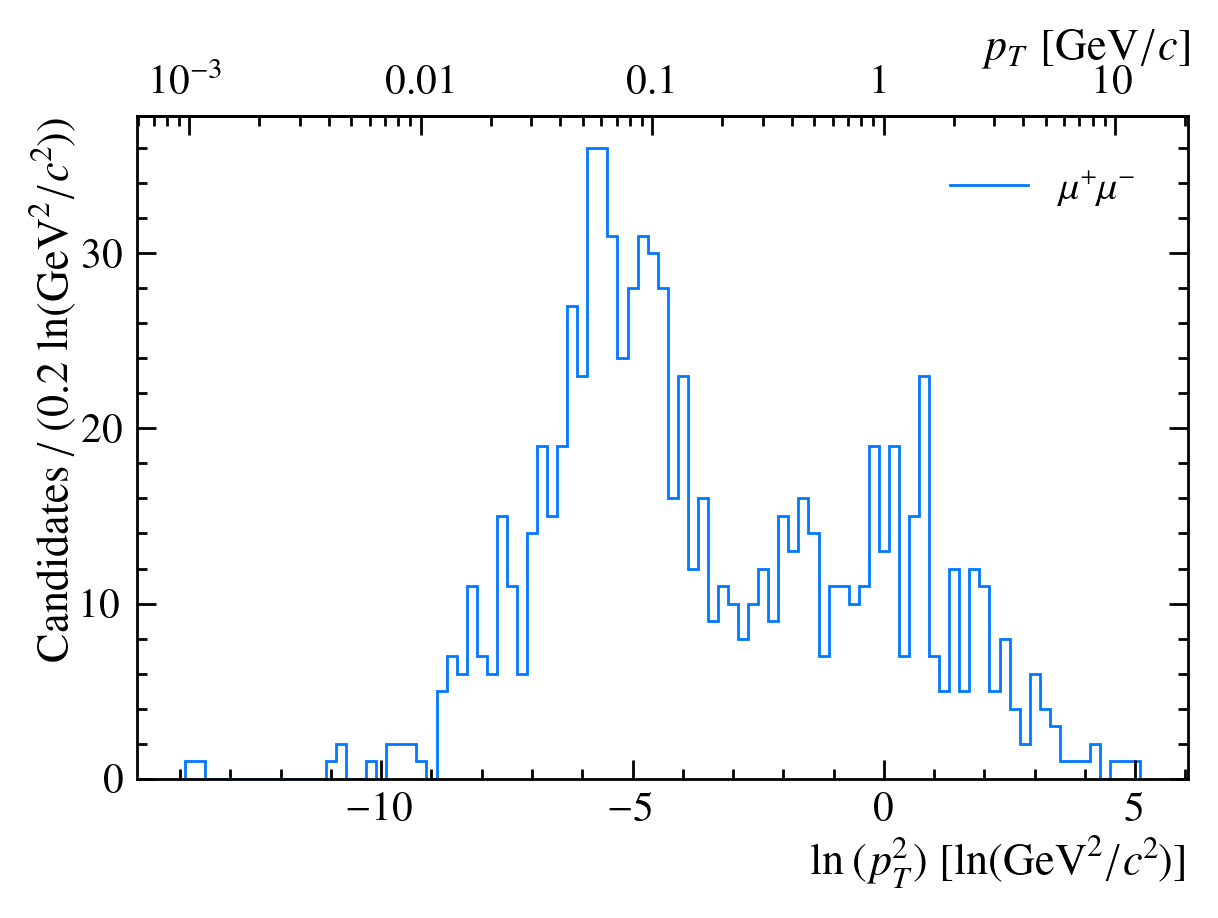

In [4]:
fig, ax = histogram_fig(
    [HistogramPlot(log_pt_squared, r"$\mu^+\mu^-$", bins=0.2)],
    False,
    xlabel = r"$\ln{(p_T^2)}$",
    unit_tex = r"\ln(\mathrm{GeV}^2/c^2)"
)
add_log_pt_axis(ax, "GeV")
# ax.axvline(0, color="k", linewidth=1.5, label=r"$1 \ \mathrm{GeV}/c$", ls="--")
# ax.legend()

Histogram not saved to file


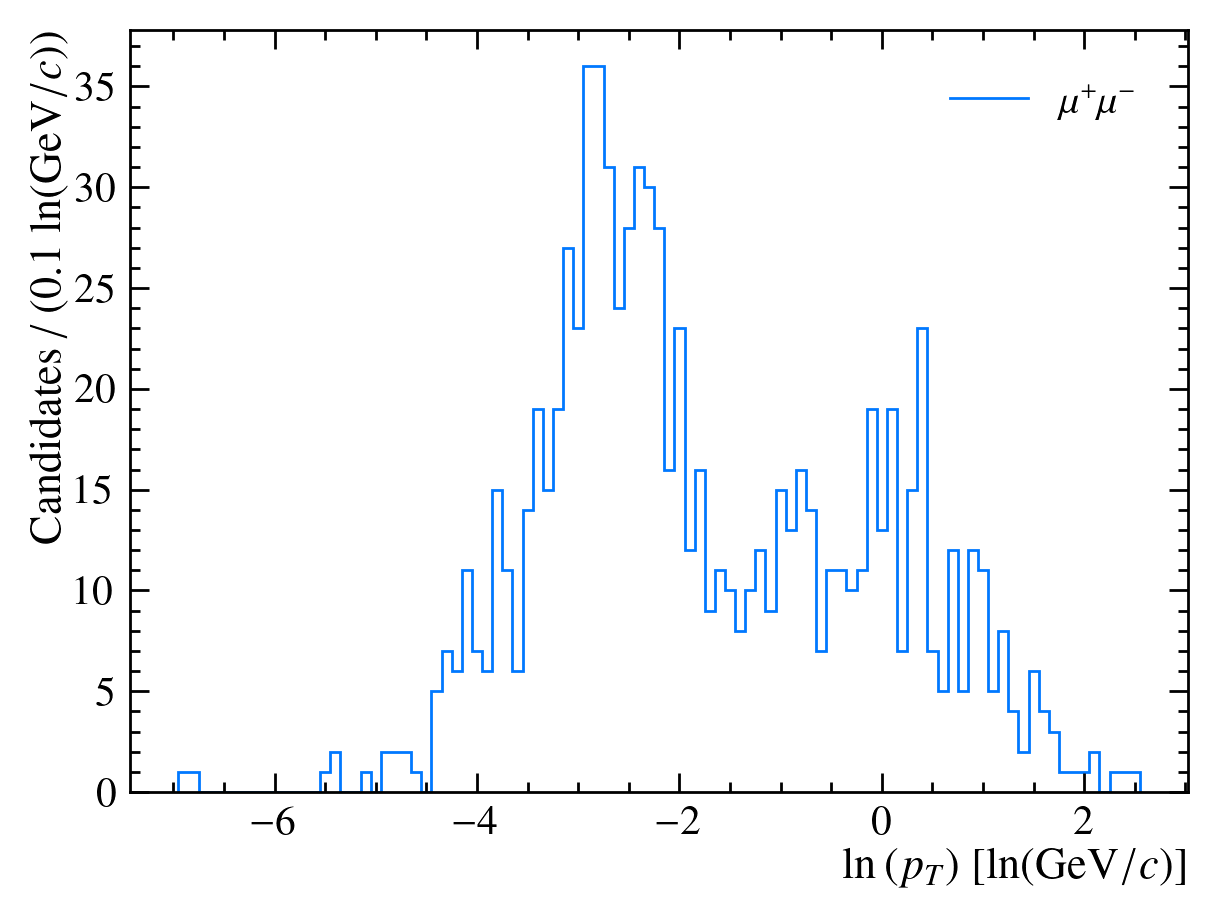

In [5]:
fig, ax = histogram_fig(
    [HistogramPlot(np.log(pt_total), r"$\mu^+\mu^-$", bins=0.1)],
    False,
    xlabel = r"$\ln{(p_T)}$",
    unit_tex = r"\ln(\mathrm{GeV}/c)"
)

In [6]:
import json, pprint

json_path = "/dice/projects/LHCb/PbPb_MSCi/01_Fit_coherent_contributions/Fit_result.json"

with open(json_path, "r") as f:
    fit_result = json.load(f)

pprint.pprint(fit_result)

{'MC_Jpsi_coherent': {'frac': [0.2402276472568088,
                               0.2599988046948141,
                               0.03873097893863867,
                               0.01694354068303766,
                               0.4440990284267008],
                      'mu': [-7.075512226970559,
                             -5.127704047562978,
                             -8.713472842772589,
                             -3.4615742707220543,
                             -5.967428338191095],
                      'sigma': [1.1752959608067084,
                                0.525521968640623,
                                1.8269359166309118,
                                0.24639699182042782,
                                0.7782239242622648],
                      'yield_model': [367130.62272151,
                                      397346.1180028683,
                                      59191.05722729458,
                                      25894.157950192166,
       

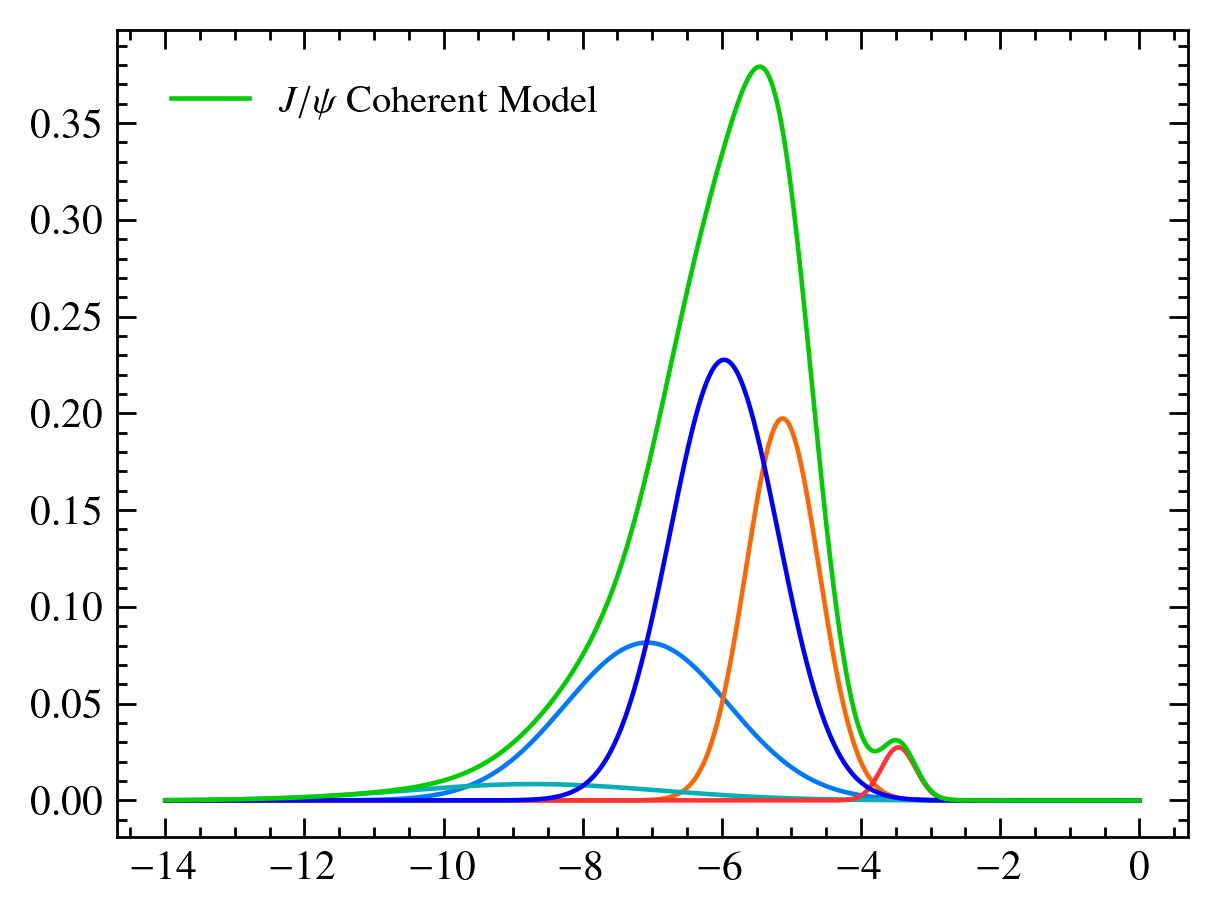

In [7]:
import scipy.stats

x = np.linspace(-14, 0, 1000)

fig, ax = plt.subplots()

MC_jpsi_coh = fit_result["MC_Jpsi_coherent"]
gaussians = []
for (mu, sigma, _yield_model, frac) in zip(MC_jpsi_coh["mu"], MC_jpsi_coh["sigma"], MC_jpsi_coh["yield_model"], MC_jpsi_coh["frac"]):
    y = scipy.stats.norm.pdf(x, mu, sigma)*frac
    gaussians.append(y)
    ax.plot(x, y)

ax.plot(x, sum(gaussians), label=r"$J/\psi$ Coherent Model")
ax.legend()




In [8]:
import zfit

/software/ai21208/Code/venv/lib/python3.12/site-packages/zfit/__init__.py:60: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(
2025-03-19 15:52:17.293501: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742399537.309591 2441598 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742399537.314763 2441598 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [9]:
def gauss_sum(obs, mus, sigmas, fracs):
    gaussians = []
    for mu, sigma, frac in zip(mus, sigmas, fracs):
        gaussians.append(zfit.pdf.Gauss(obs=obs, mu=mu, sigma=sigma))

    return zfit.pdf.SumPDF(gaussians, fracs[:-1])


observables = {
    "lnpt2": zfit.Space("lnpt2", -14, 5),
    "M": zfit.Space("M", 9, 20),
}
data = {
    "lnpt2": zfit.data.from_numpy(
        array=(log_pT2(df["J_psi_1S_PT"] / 1e3)).to_numpy(), obs=observables["lnpt2"]
    ),
    "M": zfit.data.from_numpy(
        array=(df["J_psi_1S_M"] / 1e3).to_numpy(), obs=observables["M"]
    ),
}
yields = {
    "Jpsi_coh_Nsig": zfit.Parameter("Jpsi_coh_Nsig", 50),
    "Jpsi_incoh_Nsig": zfit.Parameter("Jpsi_incoh_Nsig", 50),
    "Nbkg": zfit.Parameter("Nbkg", 650),
}
pdfs = {
    # coherent pdfs
    "Jpsi_coh_lnpt2": gauss_sum(
        obs=observables["lnpt2"],
        mus=MC_jpsi_coh["mu"],
        sigmas=MC_jpsi_coh["sigma"],
        fracs=MC_jpsi_coh["frac"],
    ).create_extended(yields["Jpsi_coh_Nsig"]),
    "Jpsi_coh_M": zfit.pdf.Gauss(
        obs=observables["M"],
        mu=constant.UPSILON_1S_MASS / 1e3,
        sigma=zfit.Parameter(
            "Jpsi_coh_M_sigma", constant.UPSILON_1S_SIGMA_LHCB / 1e3, floating=False
        ),
    ).create_extended(yields["Jpsi_coh_Nsig"]),

    # incoherent pdfs
    # ln pT^2: KDE
    "Jpsi_incoh_M": zfit.pdf.Gauss(
        obs=observables["M"],
        mu=constant.UPSILON_1S_MASS / 1e3,
        sigma=zfit.Parameter(
            "Jpsi_incoh_M_sigma", constant.UPSILON_1S_SIGMA_LHCB / 1e-3, floating=False
        ),
    ).create_extended(yields["Jpsi_incoh_Nsig"]),

    # background pdf
    # ln pT^2: KDE
    "bkg_M": zfit.pdf.Exponential(
        obs=observables["M"], lambda_=zfit.Parameter("bkg_M_lambda", -0.4)
    ).create_extended(yields["Nbkg"]),
}

2025-03-19 15:52:21.752296: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_SYSTEM_DRIVER_MISMATCH: system has unsupported display driver / cuda driver combination
2025-03-19 15:52:21.752440: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:262] kernel version 555.42.6 does not match DSO version 570.124.6 -- cannot find working devices in this configuration


<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2441598/2827170315.py:15: SyntaxWarning: invalid escape sequence '\m'
  [HistogramPlot(np.log((background_df["J_psi_1S_PT"]/1e3)**2), "Background candidates $(M_\mathrm{bkg} > 12 \mathrm{GeV}/c^2)$", bins=bin_width, linewidth=1.5, error=True)],
/tmp/ipykernel_2441598/2827170315.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = np.linspace(float(bkg_kde.space.lower), float(bkg_kde.space.upper), 500)


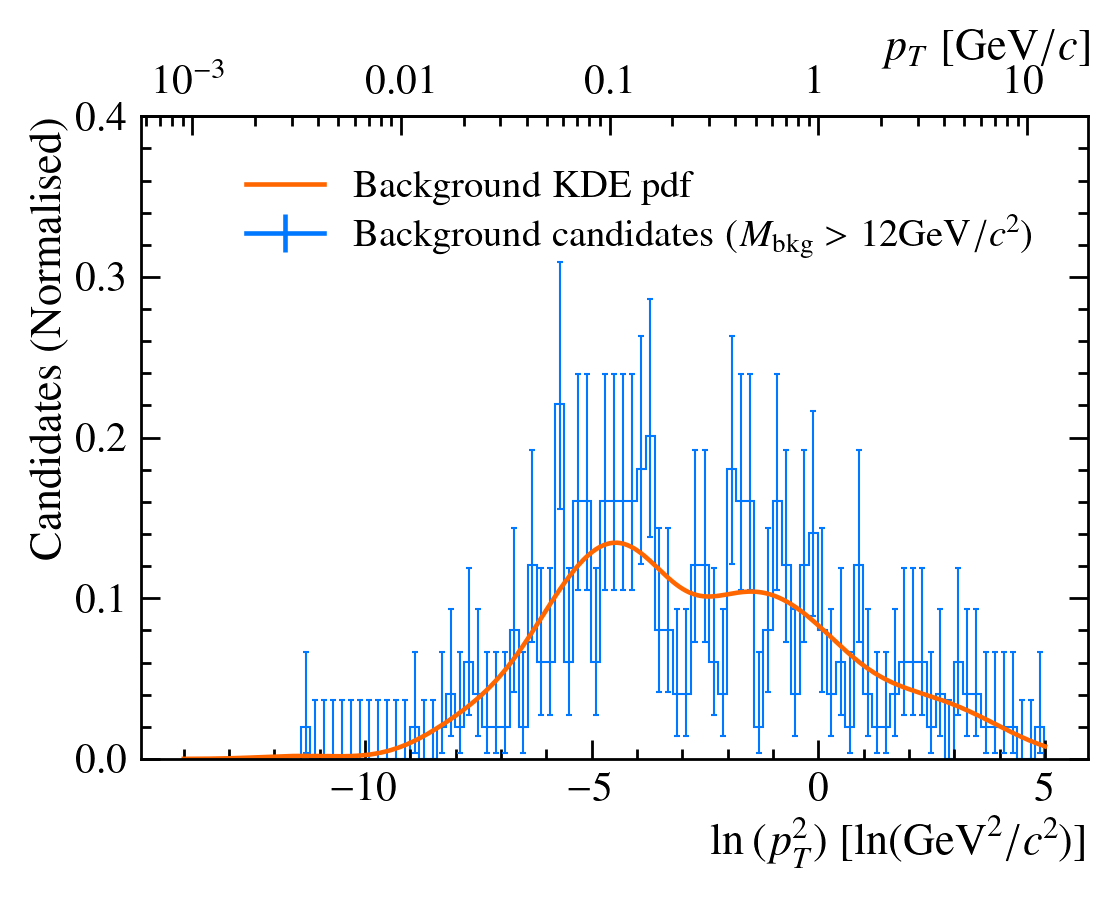

In [10]:
background_df = df[df["J_psi_1S_M"] > 12e3]

bkg_data = zfit.data.from_numpy(array=(log_pT2(background_df["J_psi_1S_PT"]/1e3)).to_numpy(), obs=observables["lnpt2"])
bkg_kde = zfit.pdf.KDE1DimExact(obs=observables["lnpt2"], data=bkg_data)

pdfs["bkg_lnpt2"] = bkg_kde
pdfs["bkg_lnpt2"].set_yield(yields["Nbkg"])

x = np.linspace(float(bkg_kde.space.lower), float(bkg_kde.space.upper), 500)
bin_width = 0.2

fig, ax = plt.subplots(figsize=(5*2.2,4*2.2))

histogram_ax(
    [HistogramPlot(np.log((background_df["J_psi_1S_PT"]/1e3)**2), "Background candidates $(M_\mathrm{bkg} > 12 \mathrm{GeV}/c^2)$", bins=bin_width, linewidth=1.5, error=True)],
    ax=ax,
    xlabel = r"$\ln{(p_T^2)}$",
    unit_tex = r"\ln(\mathrm{GeV}^2/c^2)",
    density=True,
    ylim=[0,0.4]
)
ax.plot(x, bkg_kde.pdf(x), label="Background KDE pdf")
add_log_pt_axis(ax, "GeV")
ax.legend()

fig.savefig("figures/Report/KDE.svg")

In [11]:
coh_model = zfit.pdf.ProductPDF(pdfs=[pdfs["Jpsi_coh_M"], pdfs["Jpsi_coh_lnpt2"]]).create_extended(yields["Jpsi_coh_Nsig"])
# incoh_model = zfit.pdf.ProductPDF(pdfs=[pdfs["Jpsi_incoh_M"], pdfs["Jpsi_incoh_lnpt2"]]).create_extended(yields["Jpsi_incoh_Nsig"])
bkg_model = zfit.pdf.ProductPDF(pdfs=[pdfs["bkg_M"], pdfs["bkg_lnpt2"]]).create_extended(yields["Nbkg"])

total_model = zfit.pdf.SumPDF(pdfs=[coh_model, bkg_model])

/tmp/ipykernel_2441598/1625621538.py:1: UserWarning: As `copy` is not yet properly implemented, this may fails (for ProductPDF for example?). Thiswill be fixed in the future.
  coh_model = zfit.pdf.ProductPDF(pdfs=[pdfs["Jpsi_coh_M"], pdfs["Jpsi_coh_lnpt2"]]).create_extended(yields["Jpsi_coh_Nsig"])
/tmp/ipykernel_2441598/1625621538.py:3: UserWarning: As `copy` is not yet properly implemented, this may fails (for ProductPDF for example?). Thiswill be fixed in the future.
  bkg_model = zfit.pdf.ProductPDF(pdfs=[pdfs["bkg_M"], pdfs["bkg_lnpt2"]]).create_extended(yields["Nbkg"])


In [ ]:
mass_data = (df["J_psi_1S_M"]/1e3).to_numpy()
lnpt2_data = (log_pT2(df["J_psi_1S_PT"]/1e3)).to_numpy()

combined_array = np.column_stack((mass_data, lnpt2_data))

total_data = zfit.Data.from_numpy(
    obs=["M", "lnpt2"],
    array=combined_array
)

nll = zfit.loss.ExtendedUnbinnedNLL(model=total_model, data=total_data)

minimizer = zfit.minimize.Minuit()
minimum = minimizer.minimize(nll)
minimum.errors()

print(minimum)



FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_20, Composed_autoparam_21]] data=[<zfit.Data: Data obs=('M', 'lnpt2') shape=(880, 2)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 9.3e-09 │          3994.09 |  10012.61 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name             value  (rounded)               errors    at limit
-------------  ------------------  -------------------  ----------
Jpsi_coh_Nsig             41.9029  -    7.9   +    8.7       False
Nbkg                      838.094  -     29   +     30       False
bkg_M_lambda            -0.298991  -  0.01

Histogram not saved to file


/tmp/ipykernel_2441598/4243462704.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = np.linspace(float(observables["lnpt2"].lower), float(observables["lnpt2"].upper), 500)


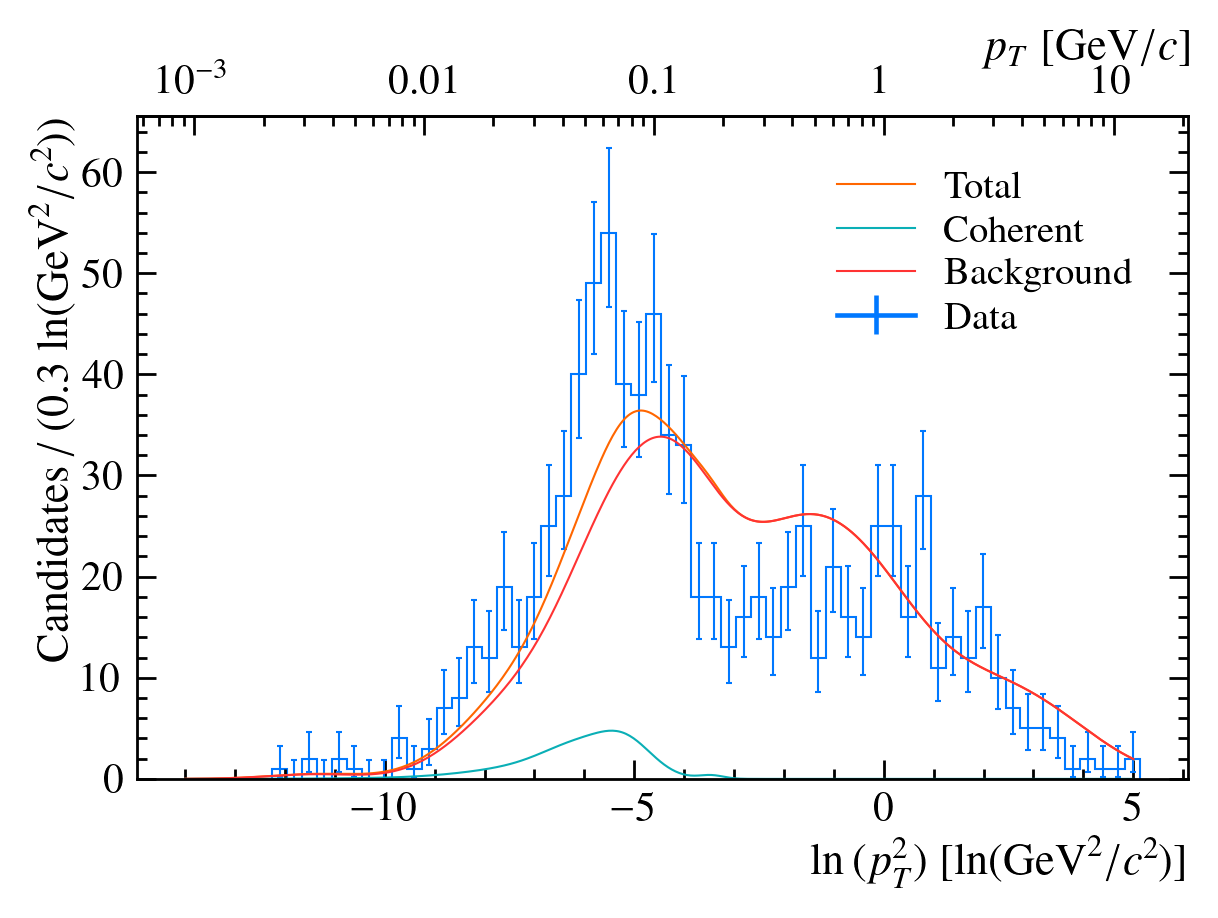

In [13]:
bin_width = 0.3
fig, ax = histogram_fig(
    [HistogramPlot(log_pT2(df["J_psi_1S_PT"]/1e3), "Data", bins=bin_width, linewidth=1.5, error=True)],
    False,
    xlabel = r"$\ln{(p_T^2)}$",
    unit_tex = r"\ln(\mathrm{GeV}^2/c^2)",
)

x = np.linspace(float(observables["lnpt2"].lower), float(observables["lnpt2"].upper), 500)
y = total_model.create_projection_pdf(obs="lnpt2").ext_pdf(x)*bin_width
ax.plot(x, y, label="Total", linewidth=1.5)
ax.plot(x, pdfs["Jpsi_coh_lnpt2"].ext_pdf(x)*bin_width, label="Coherent", linewidth=1.5)
# ax.plot(x, pdfs["Jpsi_incoh_lnpt2"].ext_pdf(x)*bin_width, label="Incoherent", linewidth=1.5)
ax.plot(x, pdfs["bkg_lnpt2"].ext_pdf(x)*bin_width, label="Background", linewidth=1.5)
add_log_pt_axis(ax, "GeV")
ax.legend()

fig.savefig("figures/Report/Upsilon_pt_model.svg")

/tmp/ipykernel_2441598/3160284197.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = np.linspace(float(observables["M"].lower), float(observables["M"].upper), 500)


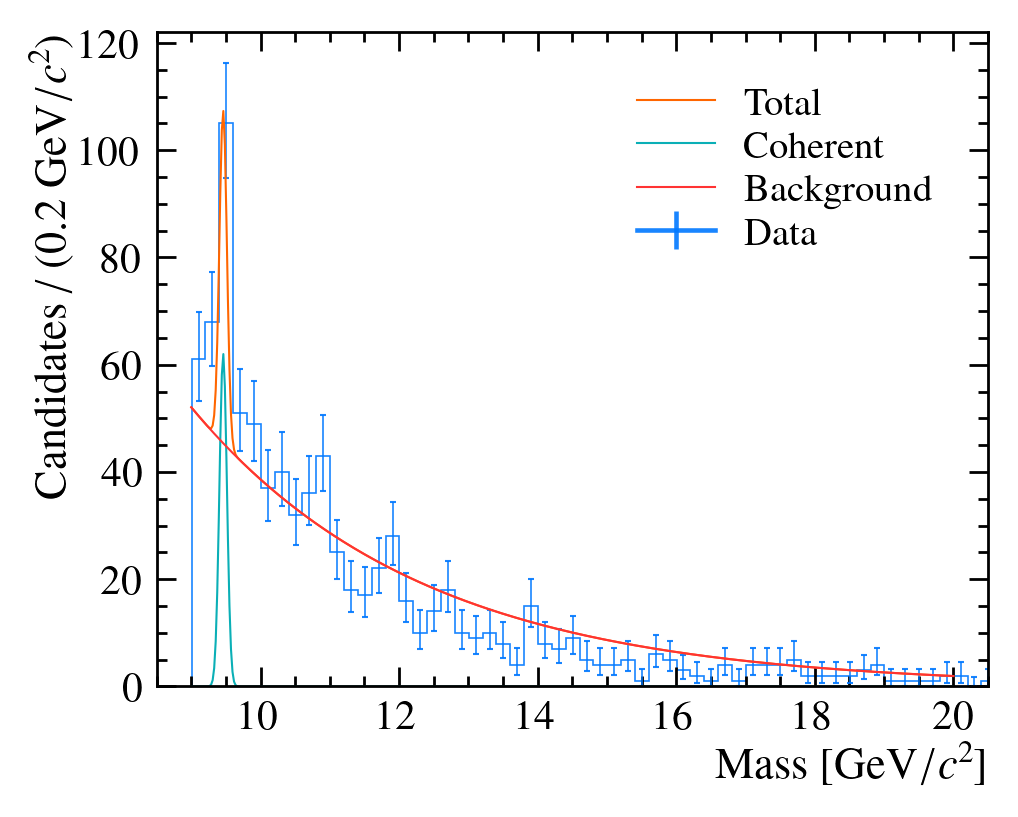

In [14]:
bin_width = 200/1e3
fig, ax = plt.subplots(figsize=(5*2,4*2))

histogram_ax(
    [HistogramPlot(df["J_psi_1S_M"]/1e3, "Data", bins=bin_width, linewidth=1.2, error=True, alpha=0.9)],
    ax,
    xlabel = r"Mass",
    unit_tex = r"\mathrm{GeV}/c^2",
    xlim=[8.5, 20.5]
)

x = np.linspace(float(observables["M"].lower), float(observables["M"].upper), 500)
y = total_model.create_projection_pdf(obs="M").ext_pdf(x)*bin_width
ax.plot(x, y, label="Total", linewidth=1.5)
ax.plot(x, pdfs["Jpsi_coh_M"].ext_pdf(x)*bin_width, label="Coherent", linewidth=1.5)
# ax.plot(x, pdfs["Jpsi_incoh_M"].ext_pdf(x)*bin_width, label="Incoherent", linewidth=1.5)
ax.plot(x, pdfs["bkg_M"].ext_pdf(x)*bin_width, label="Background", linewidth=1.5)
ax.legend()

# add_log_pt_axis(ax, "MeV")

fig.savefig("figures/Report/Upsilon_mass_model.svg")

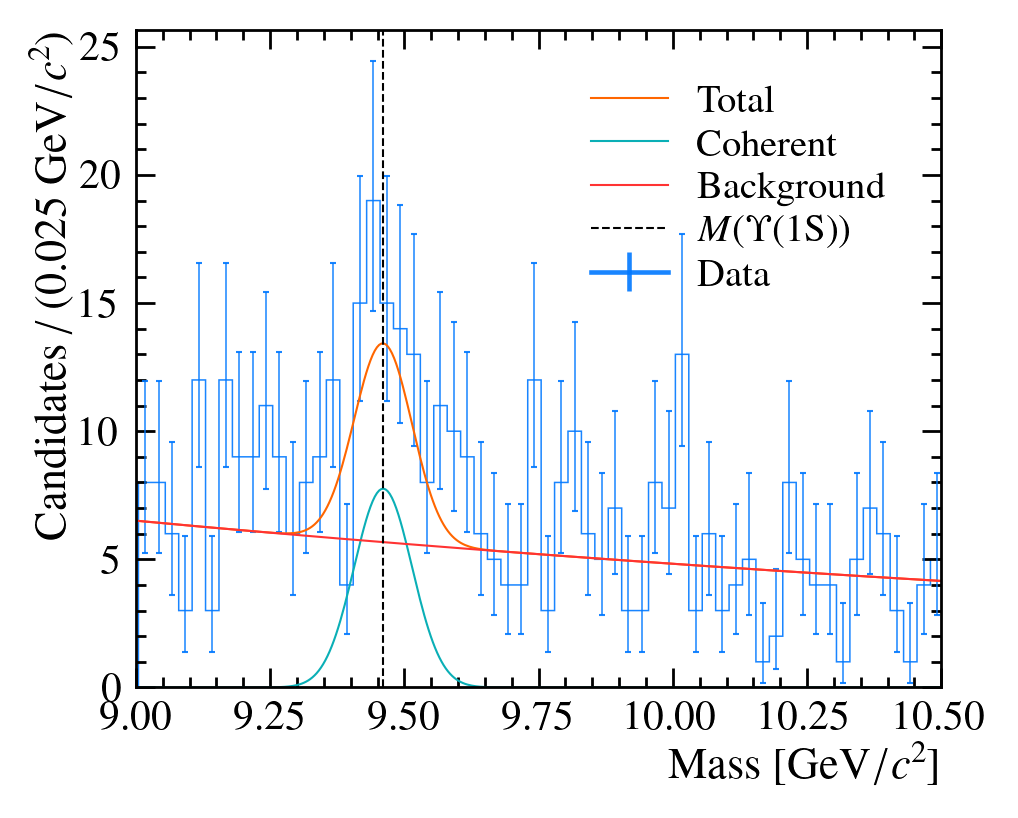

In [15]:
bin_width = 25/1e3

fig, ax = plt.subplots(figsize=(5*2,4*2))

histogram_ax(
    [HistogramPlot(df["J_psi_1S_M"]/1e3, "Data", bins=bin_width, linewidth=1.1, error=True, alpha=0.9)],
    ax=ax,
    xlabel = r"Mass",
    unit_tex = r"\mathrm{GeV}/c^2",
    xlim=[9, 10.5]
)

x = np.linspace(9, 11, 500)
y = total_model.create_projection_pdf(obs="M").ext_pdf(x)*bin_width
ax.plot(x, y, label="Total", linewidth=1.5)
ax.plot(x, pdfs["Jpsi_coh_M"].ext_pdf(x)*bin_width, label="Coherent", linewidth=1.5)
# ax.plot(x, pdfs["Jpsi_incoh_M"].ext_pdf(x)*bin_width, label="Incoherent", linewidth=1.5)
ax.plot(x, pdfs["bkg_M"].ext_pdf(x)*bin_width, label="Background", linewidth=1.5)

add_upsilon(ax, scale=1/1000, xS=range(1,2))
ax.legend()

fig.savefig("figures/Report/Upsilon_mass_model_close.svg")

In [16]:
M_fit_pdf = total_model.create_projection_pdf(obs="M")
lnpt2_fit_pdf = total_model.create_projection_pdf(obs="lnpt2")

n = 1e6
M_sample = M_fit_pdf.sample(n=n).to_numpy()
lnpt2_sample = lnpt2_fit_pdf.sample(n=n).to_numpy()

Histogram not saved to file


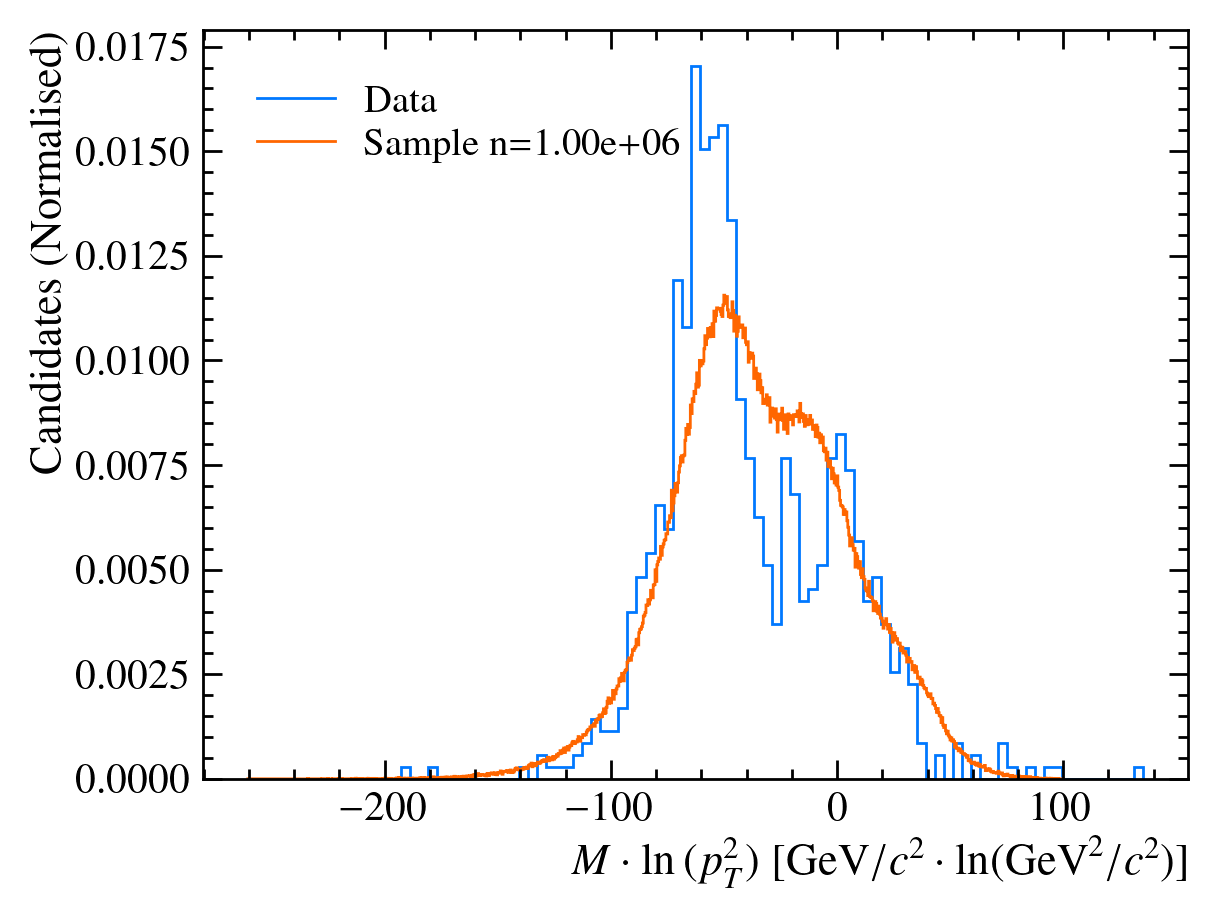

In [17]:
bin_width = 4
fig, ax = histogram_fig(
    [HistogramPlot((df["J_psi_1S_M"]/1e3)*log_pT2(df["J_psi_1S_PT"]/1e3), "Data", bins=bin_width),
     HistogramPlot(M_sample*lnpt2_sample, f"Sample {n=:.2e}", bins=bin_width/10)],
    False,
    xlabel = r"$M \cdot \ln{(p_T^2)}$",
    unit_tex = r"\mathrm{GeV}/c^2 \cdot \ln(\mathrm{GeV}^2/c^2)",
    density=True
)

In [18]:
M_vals = np.linspace(8.5, 20, 20)
lnpt2_vals = np.linspace(-14, 0, 20)
X, Y = np.meshgrid(M_vals, lnpt2_vals)

# Evaluate the PDF from zfit on the grid
pdf_vals = np.array([
    [total_model.pdf(np.array([[M, lnpt2]])).numpy()[0] for M in M_vals] 
    for lnpt2 in lnpt2_vals
])

[Text(1, 0, 'Mass'), Text(0, 1, '$\\ln(p_T^2)$')]

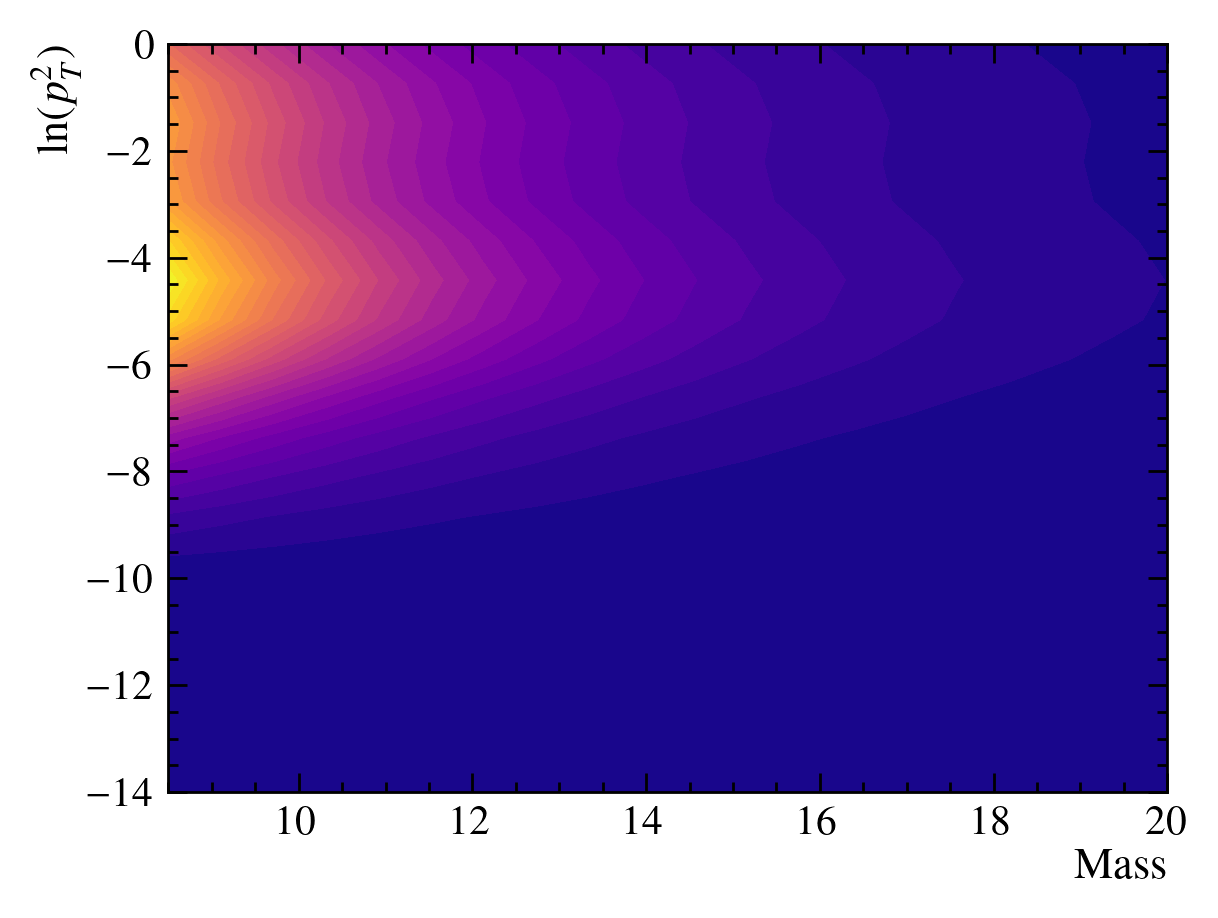

In [19]:
fig, ax = plt.subplots()

ax.contourf(X, Y, pdf_vals, levels=30, cmap="plasma")  # Adjust cmap as needed
ax.set(xlabel="Mass", ylabel=r"$\ln(p_T^2)$")

[(-14.0, 0.0), (8.5, 20.0)]

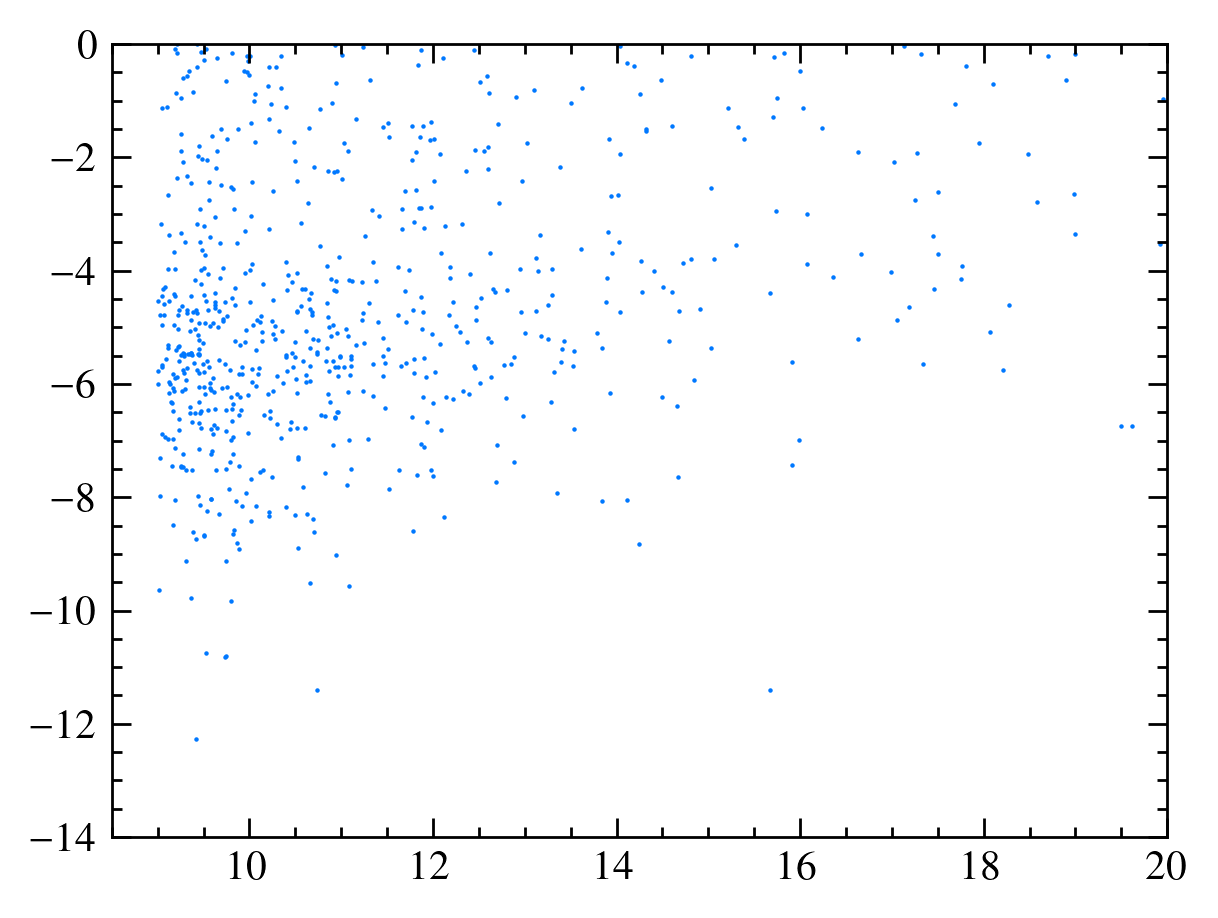

In [20]:
fig, ax = plt.subplots()
ax.scatter(df["J_psi_1S_M"]/1e3, log_pT2(df["J_psi_1S_PT"]/1e3), s=1.5)
ax.set(ylim=[-14,0], xlim=[8.5,20])